# PHT3D Example 3: MF6PQC validation

The markers are direct outputs from the official PHT3D 2.10 Example 3 model (`PHT3D001.ACN`–`PHT3D019.ACN` and `pht3d.sel`). The lines are MF6PQC results. The comparison times are 6, 12, and 24 days.

In [6]:
import sys
from pathlib import Path

sys.dont_write_bytecode = True
CASE_NAME = "ex003_PHT3D_03"
candidates = (
    candidate
    for base in (Path.cwd(), *Path.cwd().parents)
    for candidate in (base, base / "examples" / CASE_NAME)
)
CASE_DIR = next(
    (
        path.resolve()
        for path in candidates
        if path.name == CASE_NAME and (path / "modflow_model.py").is_file()
    ),
    None,
)
if CASE_DIR is None:
    raise FileNotFoundError(f"Cannot locate examples/{CASE_NAME} from {Path.cwd()}")
EXAMPLES_DIR = CASE_DIR.parent
if str(EXAMPLES_DIR) not in sys.path:
    sys.path.insert(0, str(EXAMPLES_DIR))

from example_utils import load_results, read_headings, restore_archives, runtime_path, time_indices

CASE_FILE = CASE_DIR / "run.py"
INPUT_DIR = CASE_DIR / "input_data"
OUTPUT_DIR = runtime_path(CASE_FILE, "output")
SIMULATION_DIR = runtime_path(CASE_FILE, "simulation")
restore_archives(OUTPUT_DIR)
restore_archives(SIMULATION_DIR)


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

plt.rcParams.update(
    {
        "font.family": "Arial",
        "font.size": 10,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "mathtext.fontset": "stix",
        "savefig.dpi": 300,
    }
)

case_dir = CASE_DIR

mf6pqc = np.load(OUTPUT_DIR / "results.npy")
headings = (OUTPUT_DIR / "results_headings.txt").read_text().splitlines()
heading_index = {name: index for index, name in enumerate(headings)}
if mf6pqc.shape != (4, 12, 80):
    raise ValueError(f"Expected MF6PQC results with shape (4, 12, 80), got {mf6pqc.shape}")

reference_keys = {
    "pH": "ph",
    "pe": "pe",
    "Calcite": "calcite",
    "Ca": "ca",
    "C(4)": "c4",
    "Siderite": "siderite",
    "Fe(2)": "fe2",
    "Fe(3)": "fe3",
    "Gibbsite": "gibbsite",
    "Al": "al",
    "S(6)": "s6",
    "Gypsum": "gypsum",
}
archive = np.load(INPUT_DIR / "PHT3D_03_results.npy")
pht3d = {name: archive[key].copy() for name, key in reference_keys.items()}
times = tuple(archive["time_days"].astype(int))
x = archive["x_m"].copy()

bad_shapes = {name: values.shape for name, values in pht3d.items() if values.shape != (3, 80)}
if bad_shapes or times != (6, 12, 24) or x.shape != (80,):
    raise ValueError(f"Unexpected official reference metadata: {bad_shapes}, {times}, {x.shape}")

time_colors = {6: "#b22222", 12: "#006400", 24: "#000080"}
mineral_scale = 1.0 / 0.35
mineral_names = {"Calcite", "Siderite", "Gibbsite", "Gypsum"}


In [8]:
records = []
for name in reference_keys:
    scale = mineral_scale if name in mineral_names else 1.0
    simulated = mf6pqc[1:, heading_index[name], :] * scale
    official = pht3d[name] * scale
    for time_index, time in enumerate(times):
        error = simulated[time_index] - official[time_index]
        records.append(
            {
                "variable": name,
                "time_days": time,
                "MAE": np.mean(np.abs(error)),
                "RMSE": np.sqrt(np.mean(error**2)),
            }
        )

error_table = pd.DataFrame(records)
display(error_table.pivot(index="variable", columns="time_days", values="MAE"))


time_days,6,12,24
variable,,,
Al,1.464916e-05,3.224762e-05,2.263584e-05
C(4),7.470598e-05,1.008985e-04,8.761874e-05
Ca,6.494751e-05,8.391038e-05,7.830637e-05
Calcite,7.620115e-05,1.093225e-04,7.993858e-05
Fe(2),2.407162e-04,3.727050e-04,4.751799e-04
Fe(3),4.465104e-08,1.124209e-07,7.825162e-08
Gibbsite,3.787136e-05,5.012177e-05,9.649544e-05
Gypsum,1.020188e-04,1.558620e-04,2.039800e-04
S(6),2.751007e-04,3.723736e-04,4.560320e-04


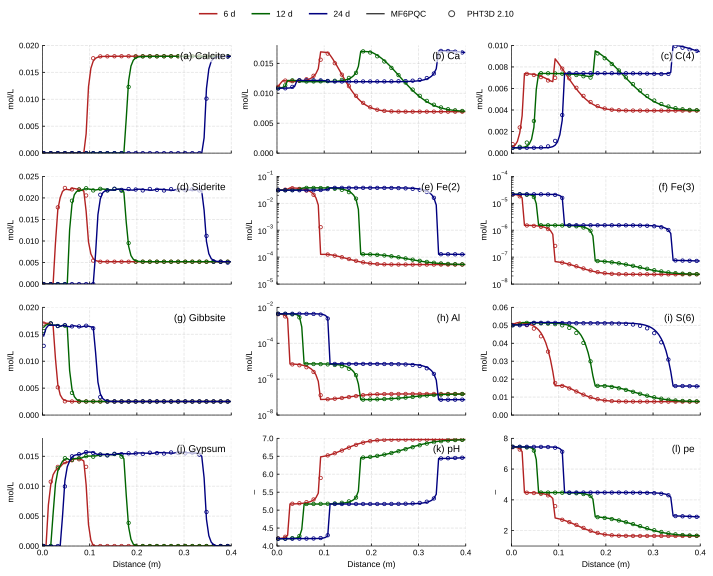

In [9]:
metrics = [
    ("Calcite", None, (0.0, 0.02)),
    ("Ca", None, (0.0, 0.018)),
    ("C(4)", None, (0.0, 0.010)),
    ("Siderite", None, (0.0, 0.025)),
    ("Fe(2)", "log", (1e-5, 1e-1)),
    ("Fe(3)", "log", (1e-8, 1e-4)),
    ("Gibbsite", None, (0.0, 0.02)),
    ("Al", "log", (1e-8, 1e-2)),
    ("S(6)", None, (0.0, 0.06)),
    ("Gypsum", None, (0.0, 0.018)),
    ("pH", None, (4.0, 7.0)),
    ("pe", None, (1.0, 8.0)),
]

fig, axes = plt.subplots(4, 3, figsize=(10, 8), sharex=True)
for panel_index, ((name, yscale, ylimits), ax) in enumerate(zip(metrics, axes.flat, strict=False)):
    scale = mineral_scale if name in mineral_names else 1.0
    for time_index, time in enumerate(times):
        color = time_colors[time]
        ax.plot(x, mf6pqc[time_index + 1, heading_index[name]] * scale, color=color, linewidth=1.4)
        ax.scatter(
            x[::3],
            (pht3d[name][time_index] * scale)[::3],
            color=color,
            marker="o",
            s=12,
            facecolors="none",
            linewidths=0.8,
        )

    ax.text(
        0.97,
        0.94,
        f"({chr(97 + panel_index)}) {name}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.7, "pad": 1.0},
    )
    if yscale:
        ax.set_yscale(yscale)
    ax.set_ylim(*ylimits)
    ax.set_xlim(0.0, 0.4)
    ax.grid(True, which="major", alpha=0.35, linestyle="--")
    ax.set_axisbelow(True)
    ax.set_ylabel("–" if name in {"pH", "pe"} else "mol/L")

for ax in axes[-1]:
    ax.set_xlabel("Distance (m)")

legend_handles = [
    *(Line2D([0], [0], color=time_colors[time], label=f"{time} d") for time in times),
    Line2D([0], [0], color="0.25", linewidth=1.4, label="MF6PQC"),
    Line2D(
        [0],
        [0],
        color="0.25",
        marker="o",
        markerfacecolor="none",
        linestyle="none",
        label="PHT3D 2.10",
    ),
]
fig.legend(
    handles=legend_handles, loc="upper center", ncol=5, frameon=False, bbox_to_anchor=(0.5, 1.0)
)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()


## 论文图 4

以下代码保持论文图的配色、字体、面板尺寸和标注，读取本案例的 `input_data/`、`output/` 与 `simulation/`。结果图保存到 `output/figures/`。

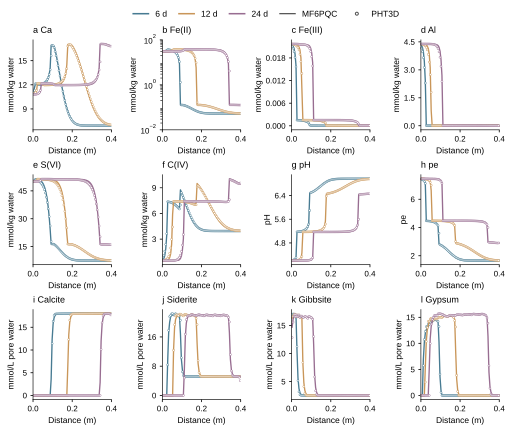

In [10]:
BASE = OUTPUT_DIR / "figures"
BASE.mkdir(exist_ok=True)

import matplotlib as mpl
from matplotlib.ticker import MaxNLocator

%matplotlib inline
%config InlineBackend.figure_format = 'svg'
W = 183 / 25.4
COL = ["#477B92", "#C99659", "#986D91"]
TIME4 = ["#477B92", "#6B9B88", "#C99659", "#986D91"]

mpl.rcdefaults()
mpl.rcParams.update(
    {
        "font.family": "Arial",
        "font.size": 9,
        "axes.titlesize": 9,
        "axes.labelsize": 8.5,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8.5,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
        "axes.linewidth": 0.65,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": False,
        "xtick.major.size": 2.5,
        "ytick.major.size": 2.5,
        "savefig.facecolor": "white",
    }
)


raw = np.load(OUTPUT_DIR / "results.npy", allow_pickle=False)
headings = (OUTPUT_DIR / "results_headings.txt").read_text().splitlines()
times = np.load(OUTPUT_DIR / "results_times.npy")
reference_keys = {
    "pH": "ph",
    "pe": "pe",
    "Calcite": "calcite",
    "Ca": "ca",
    "C(4)": "c4",
    "Siderite": "siderite",
    "Fe(2)": "fe2",
    "Fe(3)": "fe3",
    "Gibbsite": "gibbsite",
    "Al": "al",
    "S(6)": "s6",
    "Gypsum": "gypsum",
}
ref = np.load(INPUT_DIR / "PHT3D_03_results.npy", allow_pickle=False)
D = {"x_m": ref["x_m"], "time_d": ref["time_days"]}
idx = [np.flatnonzero(np.isclose(times, t)).item() for t in D["time_d"]]
for name, key in reference_keys.items():

    scale = (
        1
        if name in ["pH", "pe"]
        else 1000 / 0.35 if name in ["Calcite", "Siderite", "Gibbsite", "Gypsum"] else 1000
    )
    D[name + "_MF6PQC"] = raw[idx, headings.index(name)] * scale
    D[name + "_reference"] = ref[key] * scale


def _manuscript_layout_04(fig):
    fig.canvas.draw()
    width_pt, height_pt = fig.get_size_inches() * 72
    offsets = [
        (0, 0),
        (0, 0),
        (0, 0),
        (0, 0),
        (0, -17.25),
        (0, -17.25),
        (0, -17.25),
        (0, -17.25),
        (0, -34.5),
        (0, -34.5),
        (0, -34.5),
        (0, -34.5),
    ]
    if len(fig.axes) != len(offsets):
        raise ValueError("Manuscript panel count changed")
    for ax, (dx, dy) in zip(fig.axes, offsets, strict=True):
        pos = ax.get_position()
        ax.set_position([pos.x0 + dx / width_pt, pos.y0 - dy / height_pt, pos.width, pos.height])
    for legend in fig.legends:
        box = legend.get_bbox_to_anchor().transformed(fig.transFigure.inverted())
        legend.set_bbox_to_anchor(
            (box.x0 + 0 / width_pt, box.y0 - 6 / height_pt, box.width, box.height),
            transform=fig.transFigure,
        )


def save(n, fig, axes):
    _manuscript_layout_04(fig)
    fig.savefig(BASE / f"figure_{n:02}.png", dpi=600, bbox_inches="tight", pad_inches=0.02)
    plt.show()


def title(ax, letter, name):
    ax.set_title(f"{letter}  {name}", loc="left", pad=7, fontsize=9)


def grid(rows, cols, height, top=0.86, bottom=0.10, wspace=0.50, hspace=0.67):
    fig, axs = plt.subplots(rows, cols, figsize=(W, height), squeeze=False)
    fig.subplots_adjust(left=0.08, right=0.98, top=top, bottom=bottom, wspace=wspace, hspace=hspace)
    return fig, list(axs.flat)


def legend(fig, times, unit="yr", ref="MIN3P", colors=None):
    colors = colors or (COL if len(times) == 3 else [COL[0], COL[-1]])
    handles = [
        Line2D([], [], color=c, lw=1.5, label=f"{t:,} {unit}")
        for t, c in zip(times, colors, strict=False)
    ]
    handles += [
        Line2D([], [], color=".3", lw=1.2, label="MF6PQC"),
        Line2D([], [], color=".3", ls="none", marker="o", mfc="white", ms=3, label=ref),
    ]
    fig.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.53, 0.991),
        ncol=len(handles),
        columnspacing=1.4,
        handlelength=1.8,
    )


def fig4():
    d = D
    x = d["x_m"]
    names = [
        "Ca",
        "Fe(2)",
        "Fe(3)",
        "Al",
        "S(6)",
        "C(4)",
        "pH",
        "pe",
        "Calcite",
        "Siderite",
        "Gibbsite",
        "Gypsum",
    ]
    display = {"Fe(2)": "Fe(II)", "Fe(3)": "Fe(III)", "S(6)": "S(VI)", "C(4)": "C(IV)"}
    fig, axs = grid(3, 4, 6.7, top=0.902, bottom=0.084, wspace=0.65, hspace=0.69)
    legend(fig, [6, 12, 24], "d", "PHT3D")
    for i, (ax, name) in enumerate(zip(axs, names, strict=False)):
        for j, c in enumerate(COL):
            ax.plot(x, d[name + "_MF6PQC"][j], color=c, lw=1.35)
            ax.plot(
                x,
                d[name + "_reference"][j],
                ls="none",
                marker="o",
                ms=2,
                mfc="white",
                mec=c,
                mew=0.45,
            )
        ax.set(xlim=(0, 0.4), xticks=[0, 0.2, 0.4], xlabel="Distance (m)")
        ax.set_ylabel(
            name if name in ["pH", "pe"] else "mmol/L pore water" if i >= 8 else "mmol/kg water",
            labelpad=3,
        )
        title(ax, chr(97 + i), display.get(name, name))
        if name == "Fe(2)":
            assert np.all(d[name + "_MF6PQC"] > 0) and np.all(d[name + "_reference"] > 0)
            ax.set_yscale("log")
            ax.set_ylim(0.01, 100)
            ax.set_yticks([0.01, 1, 100])
        else:
            ax.yaxis.set_major_locator(MaxNLocator(4))
    save(4, fig, axs)


np.savez_compressed(BASE / "figure_04_data.npz", **D)
fig4()
